In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import hydroeval as he
import folium
from branca.colormap import linear
from branca.colormap import LinearColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime

In [2]:
#Define a function that calculates various metrics of comparison between modelled and observed data
def calculate_model_eval(group):
    # Extract X and y
    X = group['Modelled'].values.reshape(-1, 1)  # Reshape to ensure X is a 2D array
    y = group['Observed'].values

    # Fit linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Calculate R-squared value
    r2 = model.score(X, y)

    # Calculate correlation coefficient R
    corr_matrix = np.corrcoef(X.flatten(), y)
    r = corr_matrix[0, 1]

    # Get predictions
    y_pred = model.predict(X)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    # Get slope and intercept
    slope = model.coef_[0]
    intercept = model.intercept_

    # Count number of values
    num_values = len(y)

    return pd.Series({'R': r, 'R2': r2, 'RMSE': rmse, 'Slope': slope, 'Intercept': intercept, 'Num_Values': num_values})
    
#Define some other model metrics
def calculate_site_solute_metrics(data):
    # Create an empty DataFrame to store the results
    results_df = pd.DataFrame()

    # Iterate over unique combinations of siteId and Solute
    for (site, var), group in data.groupby(['siteId', 'Variable']):
        # Extract Modelled and Observed data for the current site and solute
        simulations = group['Modelled'].tolist()
        evaluations = group['Observed'].tolist()

        # Calculate NSE and KGE metrics
        nse = he.evaluator(he.nse, simulations, evaluations)
        kge, r, alpha, beta = he.evaluator(he.kge, simulations, evaluations)

        # Create a DataFrame with the results for the current site and solute
        result = pd.DataFrame({
            'siteId': [site],
            'Variable': [var],
            'NSE': [nse[0]],  # Extracting the scalar value from the array
            'KGE': [kge[0]],  # Extracting the scalar value from the array
            #'R': [r],
            #'Alpha': [alpha],
            #'Beta': [beta]
        })

        # Append the result to the results DataFrame
        results_df = pd.concat([results_df, result], ignore_index=True)

    return results_df

In [3]:
pathData = '/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/SamplingInt_Timeseries_NADPsites'
os.chdir(pathData)
inorganics = pd.read_csv('PREC_SO4_NO3_NH4_Timeseries.SamplingInt_Summed_pairedNADPsites.csv')
nadp_df = inorganics[['siteId', 'dateOn', 'dateOff', 'SamplingInt', 'lat', 'lon', 'longitude', 'PREC_tot_mm','ppt_mm',
       'Mod_SO4_mgm2', 'Mod_NO3_mgm2', 'Mod_NH4_mgm2','SO4_mgm2', 'NO3_mgm2', 'NH4_mgm2']]
nadp_df.head()

,siteId,dateOn,dateOff,SamplingInt,lat,lon,longitude,PREC_tot_mm,ppt_mm,Mod_SO4_mgm2,Mod_NO3_mgm2,Mod_NH4_mgm2,SO4_mgm2,NO3_mgm2,NH4_mgm2
0,AB32,2016-09-13 18:40:00,2016-09-20 15:10:00,0.0,57.015707,248.75,-111.6406,22.086179,0.762,3.177832,1.885747,0.229461,NaN,NaN,NaN
1,AB32,2016-09-20 15:15:00,2016-09-28 16:00:00,1.0,57.015707,248.75,-111.6406,3.994071,0.508,1.479748,1.511172,0.188013,NaN,NaN,NaN
2,AB32,2016-09-28 16:00:00,2016-10-05 16:55:00,2.0,57.015707,248.75,-111.6406,23.925135,18.034,8.839498,12.075514,4.646642,6.888988,3.42646,0.703326
3,AB32,2016-10-05 16:55:00,2016-10-11 17:00:00,3.0,57.015707,248.75,-111.6406,4.555199,10.160,0.423942,1.087903,0.124042,NaN,NaN,NaN
4,AB32,2016-10-11 17:00:00,2016-10-18 20:00:00,4.0,57.015707,248.75,-111.6406,18.697038,13.208,5.312534,8.151663,1.206460,NaN,NaN,NaN


In [4]:
#Conduct an analysis on precip accuracy
#Step 1: Remove rows where there is no observed rain but the model is predicting rain
nadp_df = nadp_df.loc[nadp_df.ppt_mm != 0,]

#calculate the percent error between modelled and observed (|modelled - observed|/modelled)*100%
nadp_df['Precip_Perc_Error'] = ((abs(nadp_df['PREC_tot_mm'] - nadp_df['ppt_mm']))/(nadp_df['PREC_tot_mm']))*100

#Create a categorical variable that is reflective of precip accuracy
#conditions = [
#    (nadp_df['Precip_Perc_Error'] >= 0) & (nadp_df['Precip_Perc_Error'] < 11),
#    (nadp_df['Precip_Perc_Error'] >= 11) & (nadp_df['Precip_Perc_Error'] < 21)
#]

#labels = ['Excellent', 'Good']

# Create a new variable based on conditions
#nadp_df['Precip_Quality'] = np.select(conditions, labels, default='Poor')
nadp_df.head()

,siteId,dateOn,dateOff,SamplingInt,lat,lon,longitude,PREC_tot_mm,ppt_mm,Mod_SO4_mgm2,Mod_NO3_mgm2,Mod_NH4_mgm2,SO4_mgm2,NO3_mgm2,NH4_mgm2,Precip_Perc_Error
0,AB32,2016-09-13 18:40:00,2016-09-20 15:10:00,0.0,57.015707,248.75,-111.6406,22.086179,0.762,3.177832,1.885747,0.229461,NaN,NaN,NaN,96.549879
1,AB32,2016-09-20 15:15:00,2016-09-28 16:00:00,1.0,57.015707,248.75,-111.6406,3.994071,0.508,1.479748,1.511172,0.188013,NaN,NaN,NaN,87.281146
2,AB32,2016-09-28 16:00:00,2016-10-05 16:55:00,2.0,57.015707,248.75,-111.6406,23.925135,18.034,8.839498,12.075514,4.646642,6.888988,3.42646,0.703326,24.623204
3,AB32,2016-10-05 16:55:00,2016-10-11 17:00:00,3.0,57.015707,248.75,-111.6406,4.555199,10.160,0.423942,1.087903,0.124042,NaN,NaN,NaN,123.041861
4,AB32,2016-10-11 17:00:00,2016-10-18 20:00:00,4.0,57.015707,248.75,-111.6406,18.697038,13.208,5.312534,8.151663,1.206460,NaN,NaN,NaN,29.357796


In [5]:
#Create individual dataframes for dropping nans and cleaning
SO4_df = nadp_df[['siteId', 'SamplingInt', 'dateOn', 'dateOff', 'lat', 'lon', 'longitude', 'Mod_SO4_mgm2', 'SO4_mgm2']].dropna()
SO4_df['Variable'] = 'WetDep_SO4_mgm2'
SO4_df = SO4_df.rename(columns = {'Mod_SO4_mgm2':'Modelled', 'SO4_mgm2' : 'Observed'})

NO3_df = nadp_df[['siteId', 'SamplingInt', 'dateOn', 'dateOff', 'lat', 'lon', 'longitude', 'Mod_NO3_mgm2', 'NO3_mgm2']].dropna()
NO3_df['Variable'] = 'WetDep_NO3_mgm2'
NO3_df = NO3_df.rename(columns = {'Mod_NO3_mgm2':'Modelled', 'NO3_mgm2' : 'Observed'})

NH4_df = nadp_df[['siteId', 'SamplingInt', 'dateOn', 'dateOff', 'lat', 'lon', 'longitude', 'Mod_NH4_mgm2', 'NH4_mgm2']].dropna()
NH4_df['Variable'] = 'WetDep_NH4_mgm2'
NH4_df = NH4_df.rename(columns = {'Mod_NH4_mgm2':'Modelled', 'NH4_mgm2' : 'Observed'})

ppt_df = nadp_df[['siteId', 'SamplingInt', 'dateOn', 'dateOff', 'lat', 'lon', 'longitude', 'PREC_tot_mm', 'ppt_mm']].dropna()
ppt_df['Variable'] = 'Precipitation'
ppt_df = ppt_df.rename(columns = {'PREC_tot_mm':'Modelled', 'ppt_mm' : 'Observed'})

ppt_qual_df = nadp_df[['siteId', 'SamplingInt', 'Precip_Perc_Error']].dropna()
ppt_qual_df

#Final df creation
mod_nadp_clean = pd.concat([SO4_df, NO3_df, NH4_df, ppt_df])
mod_nadp_clean = pd.merge(mod_nadp_clean, ppt_qual_df, on = ['siteId', 'SamplingInt'])
mod_nadp_clean

,siteId,SamplingInt,dateOn,dateOff,lat,lon,longitude,Modelled,Observed,Variable,Precip_Perc_Error
0,AB32,2.0,2016-09-28 16:00:00,2016-10-05 16:55:00,57.015707,248.75,-111.6406,8.839498,6.888988,WetDep_SO4_mgm2,24.623204
1,AB32,2.0,2016-09-28 16:00:00,2016-10-05 16:55:00,57.015707,248.75,-111.6406,12.075514,3.426460,WetDep_NO3_mgm2,24.623204
2,AB32,2.0,2016-09-28 16:00:00,2016-10-05 16:55:00,57.015707,248.75,-111.6406,4.646642,0.703326,WetDep_NH4_mgm2,24.623204
3,AB32,2.0,2016-09-28 16:00:00,2016-10-05 16:55:00,57.015707,248.75,-111.6406,23.925135,18.034000,Precipitation,24.623204
4,AB32,5.0,2016-10-18 20:00:00,2016-10-25 18:00:00,57.015707,248.75,-111.6406,2.671013,3.940048,WetDep_SO4_mgm2,59.255854
...,...,...,...,...,...,...,...,...,...,...,...
779816,WY99,1091.0,2022-08-15 18:35:00,2022-08-25 20:33:00,43.821990,256.25,-104.1917,7.224202,10.411000,Precipitation,44.112805
779817,WY99,1094.0,2022-09-07 16:21:00,2022-09-13 16:40:00,43.821990,256.25,-104.1917,5.739371,6.096000,Precipitation,6.213726
779818,WY99,1098.0,2022-10-03 13:45:00,2022-10-11 13:15:00,43.821990,256.25,-104.1917,3.902077,2.032000,Precipitation,47.925171
779819,WY99,1100.0,2022-10-17 19:16:00,2022-10-25 16:41:00,43.821990,256.25,-104.1917,7.399603,4.572000,Precipitation,38.212905


In [ ]:
#Scatter plot of the precip percent error and also histogram
precip_df = mod_nadp_clean.loc[mod_nadp_clean['Variable'] == 'Precipitation',]
precip_df = precip_df.loc[precip_df['Precip_Perc_Error'] < 1000,]
#plt.scatter(precip_df['siteId'], precip_df['Precip_Perc_Error'], alpha = 0.2)

plt.hist(precip_df['Precip_Perc_Error'], bins=range(0, 1001, 10), edgecolor='black')
plt.xlabel('Precipitation Percentage Error')
plt.ylabel('Frequency')
plt.title('Histogram of Precipitation Percentage Error')
plt.xticks(np.arange(0, 1001, 50), rotation = 90)
plt.show()

In [6]:
#To test role of precip accuracy on overall model performance, need to perform comparison metrics on all data vs. 10, 20, 30, 40, 50% error threshold. 

#First create the dataframes
mod_nadp_clean_10 = mod_nadp_clean.loc[mod_nadp_clean['Precip_Perc_Error'] < 11,]
mod_nadp_clean_20 = mod_nadp_clean.loc[mod_nadp_clean['Precip_Perc_Error'] < 21,]
mod_nadp_clean_30 = mod_nadp_clean.loc[mod_nadp_clean['Precip_Perc_Error'] < 31,]
mod_nadp_clean_40 = mod_nadp_clean.loc[mod_nadp_clean['Precip_Perc_Error'] < 41,]
mod_nadp_clean_50 = mod_nadp_clean.loc[mod_nadp_clean['Precip_Perc_Error'] < 51,]
mod_nadp_clean_60 = mod_nadp_clean.loc[mod_nadp_clean['Precip_Perc_Error'] < 61,]
mod_nadp_clean_70 = mod_nadp_clean.loc[mod_nadp_clean['Precip_Perc_Error'] < 71,]
mod_nadp_clean_80 = mod_nadp_clean.loc[mod_nadp_clean['Precip_Perc_Error'] < 81,]
mod_nadp_clean_90 = mod_nadp_clean.loc[mod_nadp_clean['Precip_Perc_Error'] < 91,]
mod_nadp_clean_100 = mod_nadp_clean.loc[mod_nadp_clean['Precip_Perc_Error'] < 100,]
#mod_nadp_clean (all data, no filtering)


In [7]:
#Calculate model metrics for each of the dataframes:

#Calculate model metrics for 10% threshold data 
fit_df_10 = mod_nadp_clean_10.groupby(['siteId','lat', 'lon', 'Variable']).apply(calculate_model_eval).reset_index()
he_metrics_df_10 = calculate_site_solute_metrics(mod_nadp_clean_10)
fit_df_10 = pd.merge(fit_df_10, he_metrics_df_10, on=['siteId', 'Variable'], how='left')
fit_df_10['Error_Threshold'] = '10'

#Calculate model metrics for 20% threshold data 
fit_df_20 = mod_nadp_clean_20.groupby(['siteId','lat', 'lon', 'Variable']).apply(calculate_model_eval).reset_index()
he_metrics_df_20 = calculate_site_solute_metrics(mod_nadp_clean_20)
fit_df_20 = pd.merge(fit_df_20, he_metrics_df_20, on=['siteId', 'Variable'], how='left')
fit_df_20['Error_Threshold'] = '20'

#Calculate model metrics for 30% threshold data 
fit_df_30 = mod_nadp_clean_30.groupby(['siteId','lat', 'lon', 'Variable']).apply(calculate_model_eval).reset_index()
he_metrics_df_30 = calculate_site_solute_metrics(mod_nadp_clean_30)
fit_df_30 = pd.merge(fit_df_30, he_metrics_df_30, on=['siteId', 'Variable'], how='left')
fit_df_30['Error_Threshold'] = '30'

#Calculate model metrics for 40% threshold data 
fit_df_40 = mod_nadp_clean_40.groupby(['siteId','lat', 'lon', 'Variable']).apply(calculate_model_eval).reset_index()
he_metrics_df_40 = calculate_site_solute_metrics(mod_nadp_clean_40)
fit_df_40 = pd.merge(fit_df_40, he_metrics_df_40, on=['siteId', 'Variable'], how='left')
fit_df_40['Error_Threshold'] = '40'

#Calculate model metrics for 50% threshold data 
fit_df_50 = mod_nadp_clean_50.groupby(['siteId','lat', 'lon', 'Variable']).apply(calculate_model_eval).reset_index()
he_metrics_df_50 = calculate_site_solute_metrics(mod_nadp_clean_50)
fit_df_50 = pd.merge(fit_df_50, he_metrics_df_50, on=['siteId', 'Variable'], how='left')
fit_df_50['Error_Threshold'] = '50'

#Calculate model metrics for 60% threshold data 
fit_df_60 = mod_nadp_clean_60.groupby(['siteId','lat', 'lon', 'Variable']).apply(calculate_model_eval).reset_index()
he_metrics_df_60 = calculate_site_solute_metrics(mod_nadp_clean_60)
fit_df_60 = pd.merge(fit_df_60, he_metrics_df_60, on=['siteId', 'Variable'], how='left')
fit_df_60['Error_Threshold'] = '60'

#Calculate model metrics for 70% threshold data 
fit_df_70 = mod_nadp_clean_70.groupby(['siteId','lat', 'lon', 'Variable']).apply(calculate_model_eval).reset_index()
he_metrics_df_70 = calculate_site_solute_metrics(mod_nadp_clean_70)
fit_df_70 = pd.merge(fit_df_70, he_metrics_df_70, on=['siteId', 'Variable'], how='left')
fit_df_70['Error_Threshold'] = '70'

#Calculate model metrics for 80% threshold data 
fit_df_80 = mod_nadp_clean_80.groupby(['siteId','lat', 'lon', 'Variable']).apply(calculate_model_eval).reset_index()
he_metrics_df_80 = calculate_site_solute_metrics(mod_nadp_clean_80)
fit_df_80 = pd.merge(fit_df_80, he_metrics_df_80, on=['siteId', 'Variable'], how='left')
fit_df_80['Error_Threshold'] = '80'

#Calculate model metrics for 90% threshold data 
fit_df_90 = mod_nadp_clean_90.groupby(['siteId','lat', 'lon', 'Variable']).apply(calculate_model_eval).reset_index()
he_metrics_df_90 = calculate_site_solute_metrics(mod_nadp_clean_90)
fit_df_90 = pd.merge(fit_df_90, he_metrics_df_90, on=['siteId', 'Variable'], how='left')
fit_df_90['Error_Threshold'] = '90'

#Calculate model metrics for 100% threshold data 
fit_df_100 = mod_nadp_clean_100.groupby(['siteId','lat', 'lon', 'Variable']).apply(calculate_model_eval).reset_index()
he_metrics_df_100 = calculate_site_solute_metrics(mod_nadp_clean_100)
fit_df_100 = pd.merge(fit_df_100, he_metrics_df_100, on=['siteId', 'Variable'], how='left')
fit_df_100['Error_Threshold'] = '100'

#Calculate model metrics for all data 
fit_df_all = mod_nadp_clean.groupby(['siteId','lat', 'lon', 'Variable']).apply(calculate_model_eval).reset_index()
he_metrics_df_all = calculate_site_solute_metrics(mod_nadp_clean)
fit_df_all = pd.merge(fit_df_all, he_metrics_df_all, on=['siteId', 'Variable'], how='left')
fit_df_all['Error_Threshold'] = 'None'


/glade/u/apps/opt/conda/envs/npl-2023a/lib/python3.9/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/glade/u/apps/opt/conda/envs/npl-2023a/lib/python3.9/site-packages/numpy/lib/function_base.py:2845: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/glade/u/apps/opt/conda/envs/npl-2023a/lib/python3.9/site-packages/numpy/lib/function_base.py:2704: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/glade/u/apps/opt/conda/envs/npl-2023a/lib/python3.9/site-packages/numpy/lib/function_base.py:2704: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/glade/u/apps/opt/conda/envs/npl-2023a/lib/python3.9/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Undefine

In [8]:
#concat together and calculate % observations loss
fit_df_comp = pd.concat([fit_df_10, fit_df_20, fit_df_30, fit_df_40, fit_df_50, fit_df_60, fit_df_70, fit_df_80, fit_df_90, fit_df_100, fit_df_all])
tot_obs = fit_df_all[['siteId', 'Variable', 'Num_Values']]
tot_obs = tot_obs.rename(columns = {'Num_Values' : 'Total_Values'})
fit_df_comp = pd.merge(fit_df_comp, tot_obs, on = ['siteId', 'Variable'])
fit_df_comp['Perc_Values_Retained'] = (fit_df_comp['Num_Values']/fit_df_comp['Total_Values'])*100
fit_df_comp.head(10)

,siteId,lat,lon,Variable,R,R2,RMSE,Slope,Intercept,Num_Values,NSE,KGE,Error_Threshold,Total_Values,Perc_Values_Retained
0,AB32,57.015707,248.75,Precipitation,0.994394,0.988820,1.631385,1.007984,-0.414471,23.0,0.988468,0.979738,10,282.0,8.156028
1,AB32,57.015707,248.75,Precipitation,0.988947,0.978016,1.904520,0.991390,-0.246318,46.0,0.977084,0.972032,20,282.0,16.312057
2,AB32,57.015707,248.75,Precipitation,0.976216,0.952998,2.821109,1.030164,-0.542854,67.0,0.952102,0.941899,30,282.0,23.758865
3,AB32,57.015707,248.75,Precipitation,0.949654,0.901843,3.890733,0.975696,-0.609612,93.0,0.895524,0.906675,40,282.0,32.978723
4,AB32,57.015707,248.75,Precipitation,0.913873,0.835164,4.892662,0.932256,-0.547343,120.0,0.815759,0.850430,50,282.0,42.553191
5,AB32,57.015707,248.75,Precipitation,0.879056,0.772740,5.601038,0.874505,-0.340332,146.0,0.727469,0.784823,60,282.0,51.773050
6,AB32,57.015707,248.75,Precipitation,0.851829,0.725612,5.982156,0.857414,-0.683189,176.0,0.656501,0.715494,70,282.0,62.411348
7,AB32,57.015707,248.75,Precipitation,0.788498,0.621730,8.043972,0.890131,-1.423942,210.0,0.563577,0.633282,80,282.0,74.468085
8,AB32,57.015707,248.75,Precipitation,0.780297,0.608864,7.800433,0.872192,-1.875359,250.0,0.518929,0.542277,90,282.0,88.652482
9,AB32,57.015707,248.75,Precipitation,0.768633,0.590797,7.824472,0.852714,-1.947679,268.0,0.480308,0.487910,100,282.0,95.035461


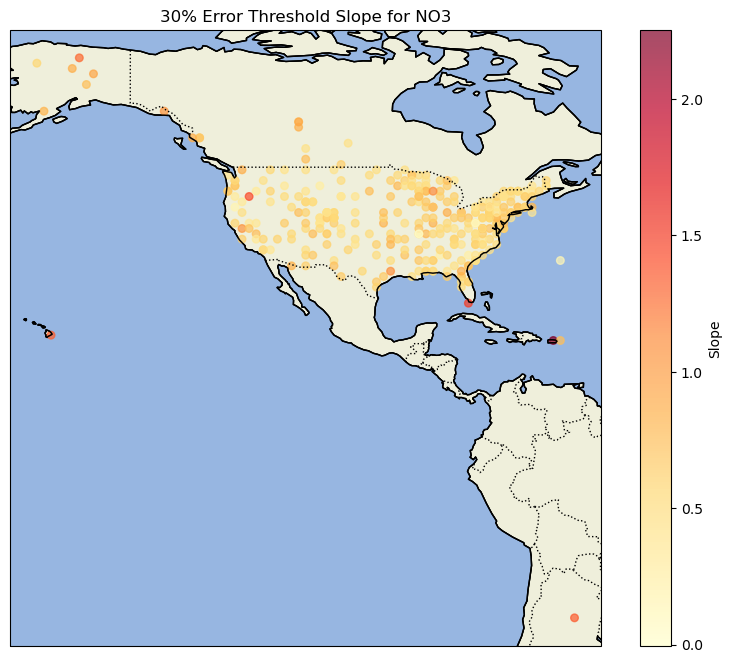

In [9]:
# Create a figure and axis with a specific projection
fit_df_comp_precip = fit_df_comp.loc[fit_df_comp['Variable'] == 'WetDep_NO3_mgm2',]
fit_df_comp_precip_30 = fit_df_comp_precip.loc[fit_df_comp_precip['Error_Threshold'] == '30',]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

# Add coastlines and other features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN, edgecolor='black')

# Plot points with color based on 'Acceptable' values
sc = ax.scatter(fit_df_comp_precip_30['lon'], fit_df_comp_precip_30['lat'], c=fit_df_comp_precip_30['Slope'], cmap='YlOrRd', s=30, alpha=0.7)

# Add colorbar
plt.colorbar(sc, ax=ax, label='Slope')
plt.title('30% Error Threshold Slope for NO3')
# Show the plot
plt.show()

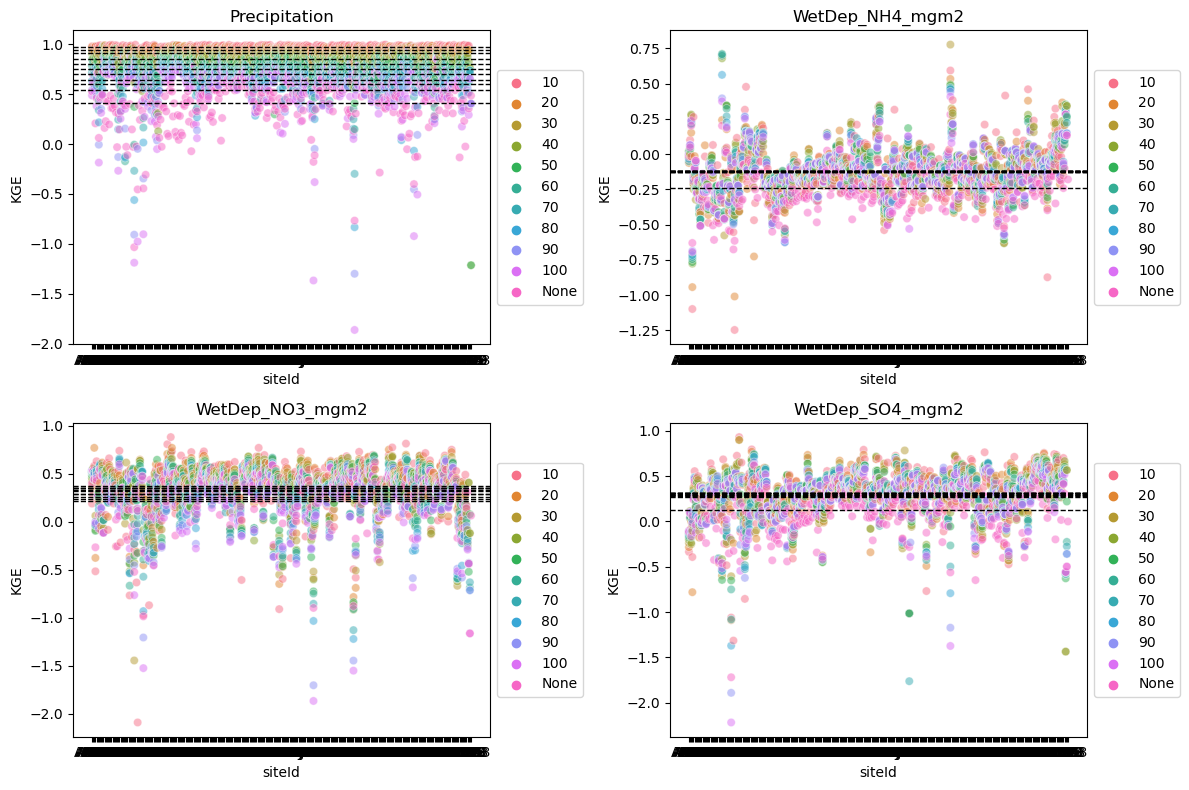

In [10]:
# Get unique variables from 'Variable' column
unique_variables = fit_df_comp['Variable'].unique()

# Create a grid for subplots
num_rows = 2
num_cols = 2
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 8))

# Iterate over unique variables and plot in the grid
for i, variable in enumerate(unique_variables):
    row = i // num_cols
    col = i % num_cols
    
    fit_df_comp_var = fit_df_comp.loc[fit_df_comp.Variable == variable]
    sns.scatterplot(data=fit_df_comp_var, x="siteId", y='KGE', hue='Error_Threshold', alpha=0.5, ax=axes[row, col])
    
    # Calculate mean of for each hue category
    means = fit_df_comp_var.groupby('Error_Threshold')['KGE'].mean()
    
    # Plot horizontal lines for each mean
    for error_threshold, mean in means.items():
        axes[row, col].axhline(y=mean, color='black', linestyle='--', linewidth=1)
    
    axes[row, col].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    axes[row, col].set_title(variable)

# Adjust layout
plt.tight_layout()
plt.show()


In [11]:
#calculate the mean of these metrics
fit_df_mean = fit_df_comp.groupby(['Variable', 'Error_Threshold'])[['Perc_Values_Retained','R','R2', 'RMSE', 'Slope','Num_Values', 'KGE']].mean().reset_index()
fit_df_se = fit_df_comp.groupby(['Variable', 'Error_Threshold'])[['Perc_Values_Retained','R','R2', 'RMSE', 'Slope','Num_Values', 'KGE']].sem().reset_index()
fit_df_mean.to_csv('/glade/u/home/demurray/External File Uploads/Variable Mean Metric Comparisons.csv')
fit_df_se.to_csv('/glade/u/home/demurray/External File Uploads/Variable SE Metric Comparisons.csv')
fit_df_mean.head(7)

,Variable,Error_Threshold,Perc_Values_Retained,R,R2,RMSE,Slope,Num_Values,KGE
0,Precipitation,10,9.023694,0.994964,0.989968,1.810284,0.986039,62.918429,0.968084
1,Precipitation,100,74.816547,0.752521,0.573751,12.231305,0.768241,518.585586,0.546627
2,Precipitation,20,17.112014,0.982149,0.964706,3.469819,0.963945,120.731928,0.944651
3,Precipitation,30,25.027906,0.962534,0.926655,5.020936,0.936968,176.600601,0.910988
4,Precipitation,40,32.993272,0.930283,0.877066,6.545279,0.838950,232.618619,0.856917
5,Precipitation,50,40.960941,0.896334,0.815122,7.958409,0.799335,287.138138,0.806494
6,Precipitation,60,48.615112,0.866536,0.752841,9.214661,0.830822,338.816817,0.754573


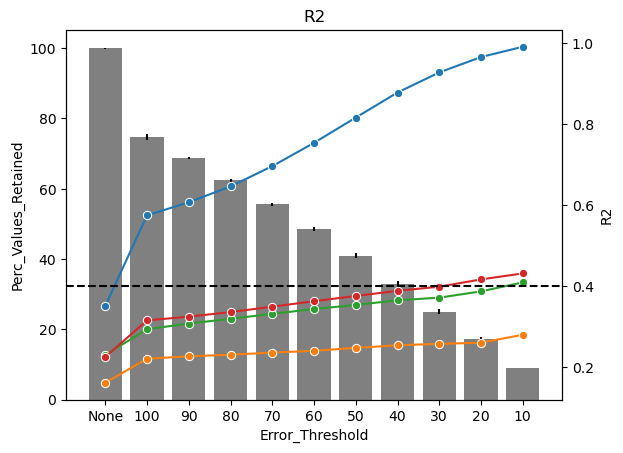

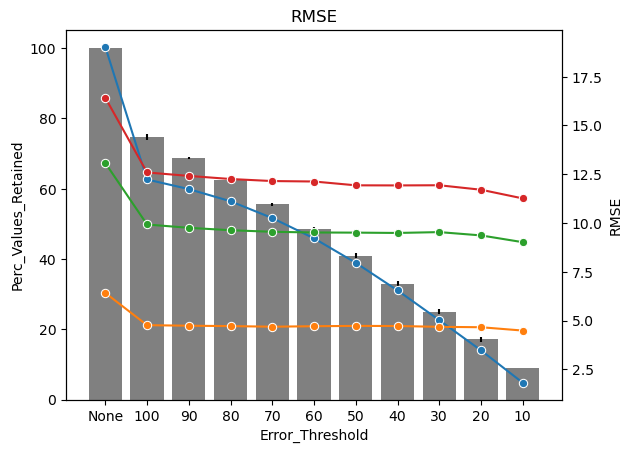

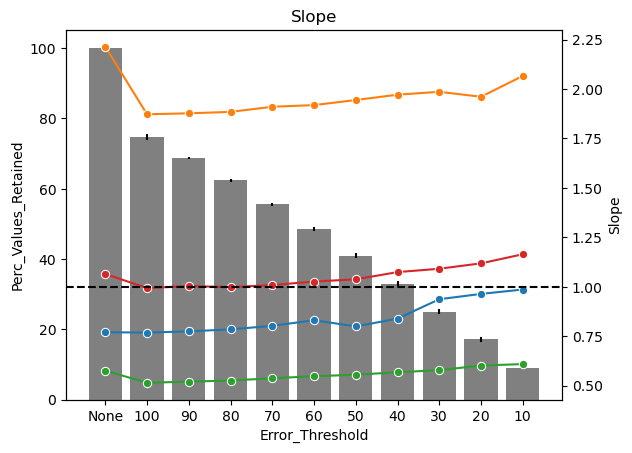

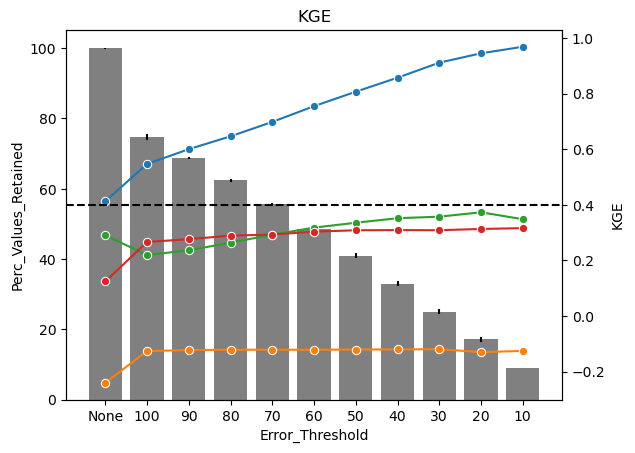

In [12]:
# Define the desired category order

fit_df_mean['Error_Threshold'] =  fit_df_mean['Error_Threshold'].astype('category')
fit_df_mean['Error_Threshold'] = fit_df_mean['Error_Threshold'].cat.reorder_categories(['None', '100', '90', '80', '70', '60', '50', '40', '30', '20', '10'])

# Filter fit_df_mean for the specific variable
variable_data = fit_df_mean.loc[fit_df_mean['Variable'] == 'Precipitation']

# R2
ax1 = sns.barplot(data=variable_data, x="Error_Threshold", y="Perc_Values_Retained", yerr=fit_df_se.loc[fit_df_se['Variable'] == 'Precipitation', 'Perc_Values_Retained'], capsize=0.1, color = 'gray')
ax2 = ax1.twinx()
sns.lineplot(data=fit_df_mean, x="Error_Threshold", y="R2", hue='Variable', ax=ax2, color='black', markers = True, marker = 'o', legend = False)
ax2.axhline(y=0.4, color='black', linestyle='--')
plt.title('R2')
plt.show()

# RMSE
ax1 = sns.barplot(data=variable_data, x="Error_Threshold", y="Perc_Values_Retained", yerr=fit_df_se.loc[fit_df_se['Variable'] == 'Precipitation', 'Perc_Values_Retained'], capsize=0.1, color = 'gray')
ax2 = ax1.twinx()
sns.lineplot(data=fit_df_mean, x="Error_Threshold", y="RMSE", hue='Variable', ax=ax2, color='black', markers = True, marker = 'o', legend = False)
plt.title('RMSE')
plt.show()

# Slope
ax1 = sns.barplot(data=variable_data, x="Error_Threshold", y="Perc_Values_Retained", yerr=fit_df_se.loc[fit_df_se['Variable'] == 'Precipitation', 'Perc_Values_Retained'], capsize=0.1, color = 'gray')
ax2 = ax1.twinx()
sns.lineplot(data=fit_df_mean, x="Error_Threshold", y="Slope", hue='Variable', ax=ax2, color='black', markers = True, marker = 'o', legend = False)
plt.title('Slope')
ax2.axhline(y=1, color='black', linestyle='--')
plt.show()

# KGE
ax1 = sns.barplot(data=variable_data, x="Error_Threshold", y="Perc_Values_Retained", yerr=fit_df_se.loc[fit_df_se['Variable'] == 'Precipitation', 'Perc_Values_Retained'], capsize=0.1, color = 'gray')
ax2 = ax1.twinx()
sns.lineplot(data=fit_df_mean, x="Error_Threshold", y="KGE", hue='Variable', ax=ax2, color='black', markers = True, marker = 'o', legend = False)
plt.title('KGE')
ax2.axhline(y=0.4, color='black', linestyle='--')
plt.show()


<AxesSubplot: xlabel='Error_Threshold', ylabel='Diff_RMSE'>

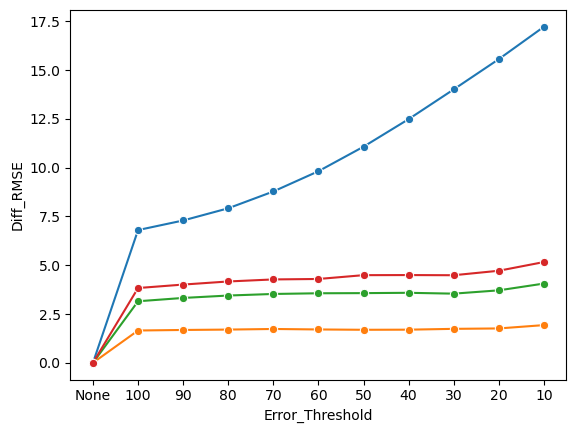

In [17]:
#Manually calculated the differnce of each metric and merged with SE to make plots
diff_se = pd.read_csv('/glade/u/home/demurray/External File Uploads/Variable Mean Metric Comparisons_DiffCalcs_SE.csv')

diff_se['Error_Threshold'] =  diff_se['Error_Threshold'].astype('category')
diff_se['Error_Threshold'] = diff_se['Error_Threshold'].cat.reorder_categories(['None', '100', '90', '80', '70', '60', '50', '40', '30', '20', '10'])

#sns.lineplot(data=diff_se, x="Error_Threshold", y="Diff_Slope", hue='Variable', color='black', markers = True, marker = 'o', legend = False)
#sns.lineplot(data=diff_se, x="Error_Threshold", y="Diff_R2", hue='Variable', color='black', markers = True, marker = 'o', legend = False)
#sns.lineplot(data=diff_se, x="Error_Threshold", y="Diff_KGE", hue='Variable', color='black', markers = True, marker = 'o', legend = False)
sns.lineplot(data=diff_se, x="Error_Threshold", y="Diff_RMSE", hue='Variable', color='black', markers = True, marker = 'o', legend = False)
